<a href="https://colab.research.google.com/github/Chadamohith/ATS-Project/blob/main/ats_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install arch hmmlearn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 12.1 MB/s eta 0:00:00


✔ Data loaded  →  shape: (2455, 6)
        Price             Close             High              Low     Open  \
0      Ticker             ^NSEI            ^NSEI            ^NSEI    ^NSEI   
1        Date               NaN              NaN              NaN      NaN   
2  2014-01-02  6221.14990234375  6358.2998046875  6211.2998046875  6301.25   

   Volume  
0   ^NSEI  
1     NaN  
2  158100  

✔ Date range: 2014-01-02 → 2023-12-29
✔ Log returns computed  →  2452 rows after dropping NaN

⏳ Fitting GARCH(1,1) ...
✔ GARCH fitted
                       Zero Mean - GARCH Model Results                        
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3187.59
Distribution:                  Normal   AIC:                           6381.18
Method:            Maximum Likelihood   BIC:                           63

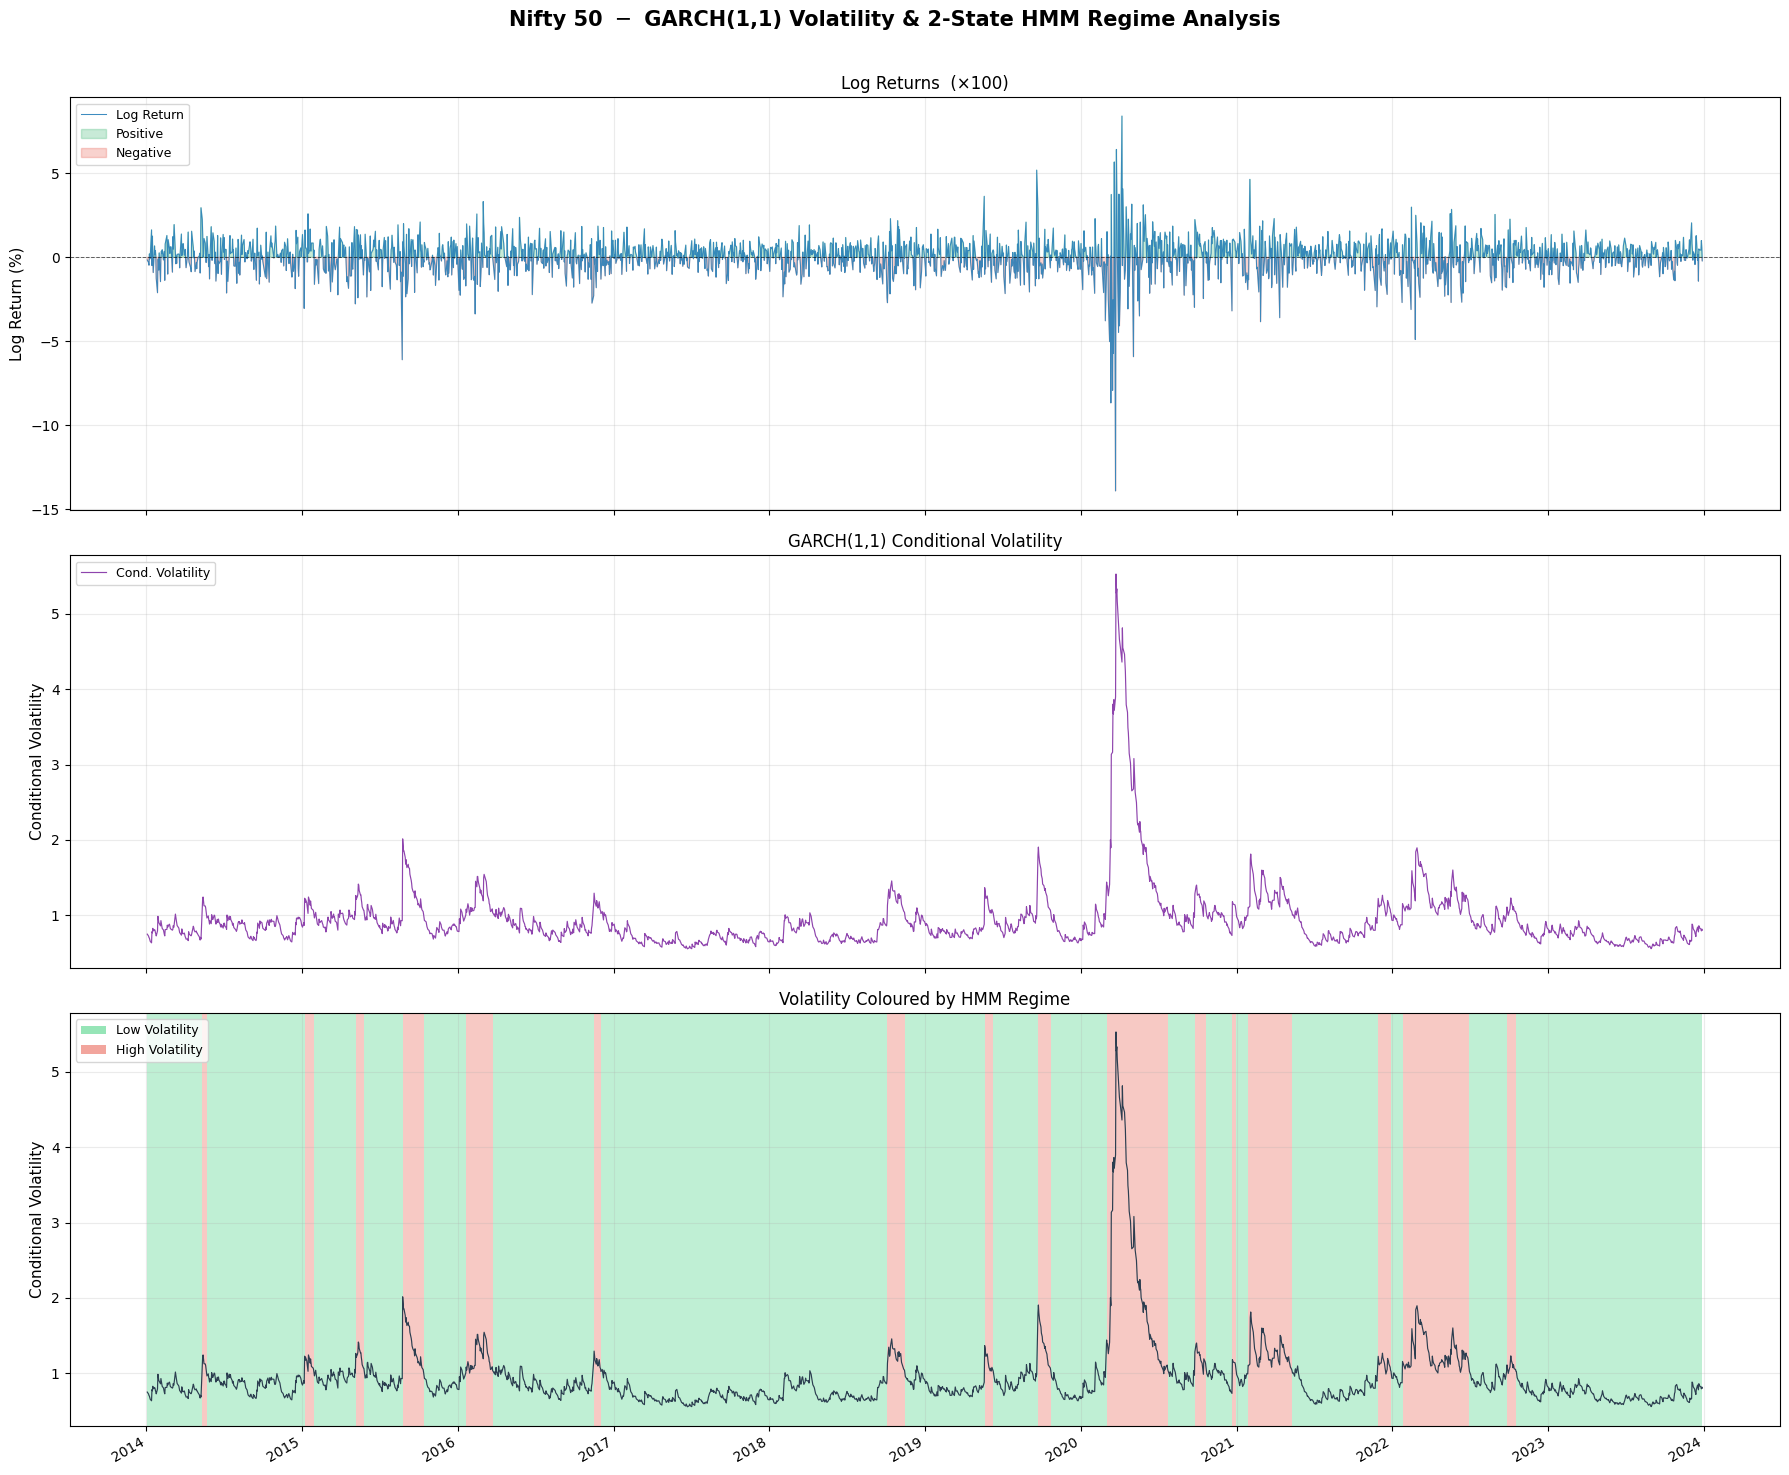

✔ Plot saved → nifty50_analysis.png


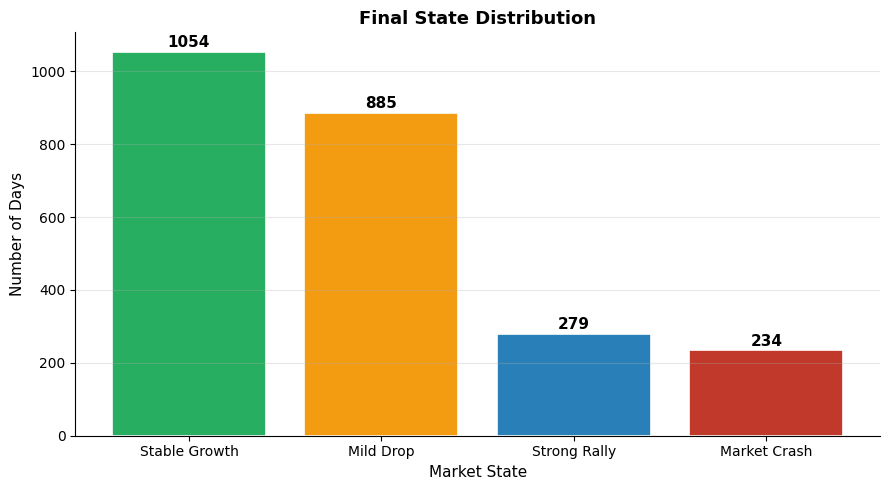

✔ Distribution chart saved → nifty50_state_distribution.png


In [ ]:
# =============================================================
#   Nifty 50 – GARCH + HMM Volatility Regime Pipeline
#   From Scratch | pandas | numpy | arch | hmmlearn | matplotlib
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

from arch import arch_model
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────
# STEP 1 : Load CSV
# ─────────────────────────────────────────────────────────────
df = pd.read_csv("nifty50_data.csv")
print("✔ Data loaded  →  shape:", df.shape)
print(df.head(3))

# --- FIX START: Correctly parse CSV and clean DataFrame ---
# Remove the first two rows as they contain metadata/junk headers
df = df.iloc[2:].copy()
# Rename the 'Price' column to 'Date'
df = df.rename(columns={'Price': 'Date'})
# Convert relevant columns to numeric, as they are likely objects after initial read and row dropping
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df['High'] = pd.to_numeric(df['High'], errors='coerce')
df['Low'] = pd.to_numeric(df['Low'], errors='coerce')
df['Open'] = pd.to_numeric(df['Open'], errors='coerce')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')
# --- FIX END: Correctly parse CSV and clean DataFrame ---

# ─────────────────────────────────────────────────────────────
# STEP 2 : Parse dates & sort chronologically
# ─────────────────────────────────────────────────────────────
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print("\n✔ Date range:", df["Date"].min().date(), "→", df["Date"].max().date())

# ─────────────────────────────────────────────────────────────
# STEP 3 : Keep only Date + Close
# ─────────────────────────────────────────────────────────────
df = df[["Date", "Close"]].copy()

# ─────────────────────────────────────────────────────────────
# STEP 4-5 : Log returns × 100, drop NaN
# ─────────────────────────────────────────────────────────────
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1)) * 100
df.dropna(subset=["Log_Return"], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"✔ Log returns computed  →  {len(df)} rows after dropping NaN")

# ─────────────────────────────────────────────────────────────
# STEP 6-7 : Fit GARCH(1,1) → Conditional Volatility
# ─────────────────────────────────────────────────────────────
print("\n⏳ Fitting GARCH(1,1) ...")
garch = arch_model(
    df["Log_Return"],
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1
)
garch_result = garch.fit(disp="off")
df["Volatility"] = garch_result.conditional_volatility
print("✔ GARCH fitted")
print(garch_result.summary())

# ─────────────────────────────────────────────────────────────
# STEP 8 : Fit 2-State Gaussian HMM on Conditional Volatility
# ─────────────────────────────────────────────────────────────
print("\n⏳ Fitting 2-State HMM ...")
vol_array = df["Volatility"].values.reshape(-1, 1)

hmm_model = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)
hmm_model.fit(vol_array)
raw_states = hmm_model.predict(vol_array)
print("✔ HMM fitted")

# ─────────────────────────────────────────────────────────────
# STEP 9 : Identify High/Low Volatility states & relabel
#           0 = Low Volatility | 1 = High Volatility
# ─────────────────────────────────────────────────────────────
mean_vol_per_state = {
    state: vol_array[raw_states == state].mean()
    for state in np.unique(raw_states)
}
print("\n  Mean volatility per raw HMM state:", mean_vol_per_state)

high_vol_state = max(mean_vol_per_state, key=mean_vol_per_state.get)
low_vol_state  = min(mean_vol_per_state, key=mean_vol_per_state.get)
print(f"  High-volatility raw state → {high_vol_state}")
print(f"  Low-volatility  raw state → {low_vol_state}")

# Relabel: 1 = High, 0 = Low
df["Vol_Regime_Num"] = np.where(raw_states == high_vol_state, 1, 0)
df["Vol_Regime"]     = df["Vol_Regime_Num"].map({0: "Low Volatility",
                                                  1: "High Volatility"})

# ─────────────────────────────────────────────────────────────
# STEP 10 : Return Sign  (+1 if return > 0, else -1)
# ─────────────────────────────────────────────────────────────
df["Return_Sign"] = np.where(df["Log_Return"] > 0, 1, -1)

# ─────────────────────────────────────────────────────────────
# STEP 11 : Final 4-State Classification
# ─────────────────────────────────────────────────────────────
def classify_state(vol_regime_num, return_sign):
    if vol_regime_num == 0 and return_sign == 1:
        return "Stable Growth"
    elif vol_regime_num == 0 and return_sign == -1:
        return "Mild Drop"
    elif vol_regime_num == 1 and return_sign == 1:
        return "Strong Rally"
    else:
        return "Market Crash"

df["Final_State"] = df.apply(
    lambda row: classify_state(row["Vol_Regime_Num"], row["Return_Sign"]),
    axis=1
)

# ─────────────────────────────────────────────────────────────
# STEP 12 : Final Output DataFrame
# ─────────────────────────────────────────────────────────────
final_df = df[["Date", "Log_Return", "Volatility",
               "Vol_Regime", "Return_Sign", "Final_State"]].copy()

print("\n" + "="*65)
print("  FINAL DATAFRAME (first 20 rows)")
print("="*65)
print(final_df.head(20).to_string(index=False))

print(f"\n  Shape          : {final_df.shape}")
print(f"\n  Vol_Regime counts:\n{final_df['Vol_Regime'].value_counts().to_string()}")
print(f"\n  Final_State counts:\n{final_df['Final_State'].value_counts().to_string()}")

# Save to CSV
final_df.to_csv("nifty50_final_output.csv", index=False)
print("\n✔ Saved → nifty50_final_output.csv")

# ─────────────────────────────────────────────────────────────
# STEP 13 : Plots
# ─────────────────────────────────────────────────────────────
COLOR_LOW  = "#2ecc71"   # green  – low  volatility
COLOR_HIGH = "#e74c3c"   # red    – high volatility

FINAL_STATE_COLORS = {
    "Stable Growth": "#27ae60",
    "Mild Drop":     "#f39c12",
    "Strong Rally":  "#2980b9",
    "Market Crash":  "#c0392b",
}

dates        = final_df["Date"].values
log_ret      = final_df["Log_Return"].values
volatility   = final_df["Volatility"].values
regime_num   = df["Vol_Regime_Num"].values   # numeric array for shading

fig, axes = plt.subplots(3, 1, figsize=(18, 15), sharex=True)
fig.suptitle(
    "Nifty 50  ─  GARCH(1,1) Volatility & 2-State HMM Regime Analysis",
    fontsize=15, fontweight="bold", y=0.98
)

# ── Panel 1 : Log Returns ────────────────────────────────────
ax1 = axes[0]
ax1.plot(dates, log_ret, color="#2980b9", linewidth=0.75, alpha=0.9, label="Log Return")
ax1.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.6)
ax1.fill_between(dates, log_ret, 0,
                 where=(log_ret >= 0), interpolate=True,
                 color="#27ae60", alpha=0.25, label="Positive")
ax1.fill_between(dates, log_ret, 0,
                 where=(log_ret < 0),  interpolate=True,
                 color="#e74c3c", alpha=0.25, label="Negative")
ax1.set_ylabel("Log Return (%)", fontsize=11)
ax1.set_title("Log Returns  (×100)", fontsize=12, pad=6)
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(True, alpha=0.25)

# ── Panel 2 : Raw Conditional Volatility ────────────────────
ax2 = axes[1]
ax2.plot(dates, volatility, color="#8e44ad", linewidth=0.85, label="Cond. Volatility")
ax2.set_ylabel("Conditional Volatility", fontsize=11)
ax2.set_title("GARCH(1,1) Conditional Volatility", fontsize=12, pad=6)
ax2.legend(fontsize=9, loc="upper left")
ax2.grid(True, alpha=0.25)

# ── Panel 3 : Volatility with HMM Regime Shading ────────────
ax3 = axes[2]

# Shade contiguous regime spans
i, n = 0, len(dates)
while i < n:
    j = i
    while j < n and regime_num[j] == regime_num[i]:
        j += 1
    shade_color = COLOR_LOW if regime_num[i] == 0 else COLOR_HIGH
    ax3.axvspan(dates[i], dates[min(j, n-1)], alpha=0.30, color=shade_color, linewidth=0)
    i = j

ax3.plot(dates, volatility, color="#2c3e50", linewidth=0.85, zorder=3)
ax3.set_ylabel("Conditional Volatility", fontsize=11)
ax3.set_title("Volatility Coloured by HMM Regime", fontsize=12, pad=6)

patch_low  = mpatches.Patch(facecolor=COLOR_LOW,  alpha=0.5, label="Low Volatility")
patch_high = mpatches.Patch(facecolor=COLOR_HIGH, alpha=0.5, label="High Volatility")
ax3.legend(handles=[patch_low, patch_high], loc="upper left", fontsize=9)
ax3.grid(True, alpha=0.25)

# Shared x-axis formatting
fig.autofmt_xdate(rotation=30, ha="right")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("nifty50_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved → nifty50_analysis.png")

# ─────────────────────────────────────────────────────────────
# BONUS : Bar chart – Final State Distribution
# ─────────────────────────────────────────────────────────────
state_counts = final_df["Final_State"].value_counts()
colors_bar   = [FINAL_STATE_COLORS[s] for s in state_counts.index]

fig2, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(state_counts.index, state_counts.values, color=colors_bar,
              edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, state_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Final State Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Days", fontsize=11)
ax.set_xlabel("Market State",   fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("nifty50_state_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Distribution chart saved → nifty50_state_distribution.png")